# Gradient Boosted Survival Model
**In this notebook, we'll train and test a gradient boosting survival model from scikit-learn to predict 6 month survival from time of first line treatment for advanced non-small cell lung cancer.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer

from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.metrics import cumulative_dynamic_auc

import matplotlib.pyplot as plt

from utils.cv_predictions import cross_validated_survival_predictions

## Import

In [2]:
dtype_map = pd.read_csv('../outputs/1L_features_training_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
train_df = pd.read_csv('../outputs/1L_features_training.csv', dtype = dtype_map)
train_df.shape

(66187, 156)

In [3]:
dtype_map = pd.read_csv('../outputs/1L_features_testing_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
test_df = pd.read_csv('../outputs/1L_features_testing.csv', dtype = dtype_map)
test_df.shape

(16552, 156)

In [4]:
censored_before_6m = (len(train_df.query('event == 0 and duration < 180', engine = 'python'))/len(train_df))*100
censored_before_12m = (len(train_df.query('event == 0 and duration < 365', engine = 'python'))/len(train_df))*100

print(f'Percentage censored before 6 months: {round(censored_before_6m, 1)}%')
print(f'Percentage censored before 12 months: {round(censored_before_12m, 1)}%')

Percentage censored before 6 months: 6.7%
Percentage censored before 12 months: 10.3%


## Preprocess

### Selecting features

#### Categorical variables

In [5]:
list(train_df.select_dtypes(include = ['category']).columns)

['Histology',
 'SmokingStatus',
 'adv_diagnosis_year',
 'Ethnicity_mod',
 'Race_mod',
 'region',
 'EGFR_status',
 'KRAS_status',
 'BRAF_status',
 'ALK_status',
 'ROS1_status',
 'MET_status',
 'RET_status',
 'NTRK_status',
 'PDL1_status',
 'PDL1_percent_staining']

In [6]:
# Percent unknown
var_dict = {}
for var in train_df.select_dtypes(include=['category']).columns:
    value_props = train_df[var].value_counts(normalize=True)
    # Combine 'unknown' and 'Unknown' if both exist
    unknown_pct = value_props.get('unknown', 0) + value_props.get('Unknown', 0) + value_props.get('Unknown/Not documented', 0)
    var_dict[var] = round(unknown_pct*100, 3)

var_dict

{'Histology': 0,
 'SmokingStatus': np.float64(0.53),
 'adv_diagnosis_year': 0,
 'Ethnicity_mod': 0,
 'Race_mod': 0,
 'region': np.float64(25.685),
 'EGFR_status': np.float64(33.327),
 'KRAS_status': np.float64(52.267),
 'BRAF_status': np.float64(53.231),
 'ALK_status': np.float64(37.119),
 'ROS1_status': np.float64(49.838),
 'MET_status': np.float64(60.201),
 'RET_status': np.float64(59.368),
 'NTRK_status': np.float64(65.623),
 'PDL1_status': np.float64(75.782),
 'PDL1_percent_staining': np.float64(90.243)}

In [7]:
# Percent positive
var_dict = {}
for var in train_df.select_dtypes(include=['category']).columns.drop(['Histology', 'SmokingStatus', 'adv_diagnosis_year', 'Ethnicity_mod', 'Race_mod', 'region', 'PDL1_percent_staining']):
    value_props = train_df[var].value_counts(normalize=True)
    pos_pct = value_props.get('positive', 0)
    var_dict[var] = round(pos_pct*100, 3)

var_dict

{'EGFR_status': np.float64(11.196),
 'KRAS_status': np.float64(13.518),
 'BRAF_status': np.float64(2.697),
 'ALK_status': np.float64(2.08),
 'ROS1_status': np.float64(0.494),
 'MET_status': np.float64(2.652),
 'RET_status': np.float64(0.663),
 'NTRK_status': np.float64(0.499),
 'PDL1_status': np.float64(10.419)}

In [8]:
categorical_var = [
    'Histology',
    'SmokingStatus',
    'EGFR_status',
    'KRAS_status',
    'BRAF_status',
    'ALK_status',
    'MET_status',
    'PDL1_status',
    'PDL1_percent_staining',
]

#### Binary variables 

In [9]:
list(train_df.select_dtypes(include = ['int']).columns)

['days_adv_to_treatment',
 'GroupStage_mod_na',
 'age',
 'sex_male',
 'ecog_newly_gte2',
 'ecog_index_na',
 'hypotension',
 'tachycardia',
 'fevers',
 'hypoxemia',
 'anticoagulant',
 'opioid',
 'steroid',
 'antibiotic',
 'diabetic_med',
 'antidepressant',
 'bone_therapy_agent',
 'immunosuppressant',
 'chf',
 'cardiac_arrhythmias',
 'valvular_disease',
 'pulm_circulation',
 'pvd',
 'htn_uncomplicated',
 'htn_complicated',
 'paralysis',
 'other_neuro',
 'chronic_pulm_disease',
 'diabetes_uncomplicated',
 'diabetes_complicated',
 'hypothyroid',
 'renal_failure',
 'liver_disease',
 'pud',
 'aids_hiv',
 'lymphoma',
 'rheumatic',
 'coagulopathy',
 'obesity',
 'weight_loss',
 'fluid',
 'blood_loss_anemia',
 'deficiency_anemia',
 'alcohol_abuse',
 'drug_abuse',
 'psychoses',
 'depression',
 'van_walraven_score',
 'lymph_met',
 'thoracic_met',
 'liver_met',
 'bone_met',
 'brain_met',
 'adrenal_met',
 'other_viscera_met',
 'other_met',
 'event']

In [10]:
# Did not include days_adv_to_treatment, age, van_walraven, or event
bin_list = [
     'GroupStage_mod_na',
     'sex_male',
     'ecog_newly_gte2',
     'ecog_index_na',
     'hypotension',
     'tachycardia',
     'fevers',
     'hypoxemia',
     'anticoagulant',
     'opioid',
     'steroid',
     'antibiotic',
     'diabetic_med',
     'antidepressant',
     'bone_therapy_agent',
     'immunosuppressant',
     'chf',
     'cardiac_arrhythmias',
     'valvular_disease',
     'pulm_circulation',
     'pvd',
     'htn_uncomplicated',
     'htn_complicated',
     'paralysis',
     'other_neuro',
     'chronic_pulm_disease',
     'diabetes_uncomplicated',
     'diabetes_complicated',
     'hypothyroid',
     'renal_failure',
     'liver_disease',
     'pud',
     'aids_hiv',
     'lymphoma',
     'rheumatic',
     'coagulopathy',
     'obesity',
     'weight_loss',
     'fluid',
     'blood_loss_anemia',
     'deficiency_anemia',
     'alcohol_abuse',
     'drug_abuse',
     'psychoses',
     'depression',
     'lymph_met',
     'thoracic_met',
     'liver_met',
     'bone_met',
     'brain_met',
     'adrenal_met',
     'other_viscera_met',
     'other_met'
]

In [11]:
# Identify binary variables with >3% prevalence 
bin_var_list = []
for bin_var in bin_list:
    if (train_df[bin_var].value_counts(normalize = True)[1] >= 0.03):
        bin_var_list.append(bin_var)

In [12]:
bin_var_list

['sex_male',
 'ecog_newly_gte2',
 'ecog_index_na',
 'hypotension',
 'tachycardia',
 'hypoxemia',
 'opioid',
 'steroid',
 'antibiotic',
 'bone_therapy_agent',
 'chf',
 'cardiac_arrhythmias',
 'pulm_circulation',
 'pvd',
 'htn_uncomplicated',
 'chronic_pulm_disease',
 'diabetes_uncomplicated',
 'diabetes_complicated',
 'hypothyroid',
 'renal_failure',
 'liver_disease',
 'coagulopathy',
 'obesity',
 'weight_loss',
 'fluid',
 'deficiency_anemia',
 'depression',
 'lymph_met',
 'thoracic_met',
 'liver_met',
 'bone_met',
 'brain_met',
 'other_met']

In [13]:
# ecog_index_na added as flags later
binary_var = [
    'sex_male',
    'ecog_newly_gte2',
    'hypotension',
    'tachycardia',
    'hypoxemia',
    'opioid',
    'steroid',
    'antibiotic',
    'bone_therapy_agent',
    'chf',
    'cardiac_arrhythmias',
    'pulm_circulation',
    'pvd',
    'htn_uncomplicated',
    'chronic_pulm_disease',
    'diabetes_uncomplicated',
    'diabetes_complicated',
    'hypothyroid',
    'renal_failure',
    'liver_disease',
    'coagulopathy',
    'obesity',
    'weight_loss',
    'fluid',
    'deficiency_anemia',
    'depression',
    'lymph_met',
    'thoracic_met',
    'liver_met',
    'bone_met',
    'brain_met',
    'other_met'
]

#### Numerical variables

In [14]:
list(train_df.select_dtypes(include = ['float64']).columns)

['GroupStage_mod',
 'days_diagnosis_to_adv',
 'ecog_index',
 'weight_index',
 'bmi_index',
 'percent_change_weight',
 'albumin',
 'alp',
 'alt',
 'ast',
 'bicarbonate',
 'bun',
 'calcium',
 'chloride',
 'creatinine',
 'hemoglobin',
 'platelet',
 'potassium',
 'sodium',
 'total_bilirubin',
 'wbc',
 'albumin_max',
 'alp_max',
 'alt_max',
 'ast_max',
 'bicarbonate_max',
 'bun_max',
 'calcium_max',
 'chloride_max',
 'creatinine_max',
 'hemoglobin_max',
 'platelet_max',
 'potassium_max',
 'sodium_max',
 'total_bilirubin_max',
 'wbc_max',
 'albumin_min',
 'alp_min',
 'alt_min',
 'ast_min',
 'bicarbonate_min',
 'bun_min',
 'calcium_min',
 'chloride_min',
 'creatinine_min',
 'hemoglobin_min',
 'platelet_min',
 'potassium_min',
 'sodium_min',
 'total_bilirubin_min',
 'wbc_min',
 'albumin_std',
 'alp_std',
 'alt_std',
 'ast_std',
 'bicarbonate_std',
 'bun_std',
 'calcium_std',
 'chloride_std',
 'creatinine_std',
 'hemoglobin_std',
 'platelet_std',
 'potassium_std',
 'sodium_std',
 'total_bilirub

In [15]:
# Added age, van_walraven_score, and days_adv_to_treatment here 
numerical_var = [
    'GroupStage_mod',
    'days_diagnosis_to_adv',
    'ecog_index',
    'weight_index',
    'bmi_index',
    'percent_change_weight',
    'albumin',
    'alp',
    'alt',
    'ast',
    'bicarbonate',
    'bun',
    'calcium',
    'chloride',
    'creatinine',
    'hemoglobin',
    'platelet',
    'potassium',
    'sodium',
    'total_bilirubin',
    'wbc',
    'alp_max',
    'alt_max',
    'ast_max',
    'calcium_max',
    'creatinine_max',
    'platelet_max',
    'potassium_max',
    'sodium_max',
    'total_bilirubin_max',
    'wbc_max',
    'albumin_min',
    'bicarbonate_min',
    'calcium_min',
    'hemoglobin_min',
    'platelet_min',
    'potassium_min',
    'sodium_min',
    'wbc_min',
    'age', 
    'van_walraven_score', 
    'days_adv_to_treatment'
]

In [16]:
all_var = categorical_var + binary_var + numerical_var

In [17]:
missing = train_df[all_var].isnull().sum()
missing[missing > 0].sort_values(ascending = False)

van_walraven_score       28252
chloride                 14592
albumin                  12363
albumin_min              11803
total_bilirubin          11586
alt                      11313
ast                      11113
alp                      11073
bicarbonate              11066
calcium                  11062
total_bilirubin_max      11006
alt_max                  10732
potassium                10631
sodium                   10577
ast_max                  10529
bicarbonate_min          10521
calcium_max              10504
calcium_min              10504
alp_max                  10499
bun                      10265
potassium_max            10093
potassium_min            10093
sodium_max               10035
sodium_min               10035
creatinine                8158
percent_change_weight     7833
creatinine_max            7680
wbc                       6902
platelet                  6823
hemoglobin                6805
wbc_min                   6568
wbc_max                   6568
platelet

In [18]:
# Create a missing flag
for x in missing[missing > 0].index:
    train_df[f'{x}_na'] = np.where(train_df[x].isna(), 1, 0)
    test_df[f'{x}_na'] = np.where(test_df[x].isna(), 1, 0)

In [19]:
# Add missing flags to binary_var (this includes ecog_index_na and GroupStage_mod_na)
binary_var = binary_var + [col for col in train_df.columns if col.endswith('_na')]

In [20]:
all_var = categorical_var + binary_var + numerical_var

In [21]:
len(all_var)

122

### Setting up Y

In [22]:
y_dtype = [('event', bool), ('duration', float)]

In [23]:
# Death status and time until event needs to be stored as a structured array to be compatible with scikit-survival
train_y = np.array([tuple(x) for x in train_df[['event', 'duration']].values], 
                   dtype = y_dtype)

test_y = np.array([tuple(x) for x in test_df[['event', 'duration']].values], 
                  dtype = y_dtype)

### Creating mini-training set for hyperparameter tuning
**Given the computational cost of hyperparameter search on the full training set, a stratified subsample of 20,000 patients is used to identify optimal hyperparameters. The final model is then trained on the complete training set using these hyperparameters before evaluating performance on the held-out test set.**

In [24]:
train_subsample_df, _ = train_test_split(
    train_df,
    train_size = 20000,
    stratify = train_df['event'],  
    random_state = 42
)

In [25]:
train_subsample_y = np.array([tuple(x) for x in train_subsample_df[['event', 'duration']].values],
                             dtype = y_dtype)

### Creating pipeline

In [26]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median'))
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown = "ignore", sparse_output = False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_var),
        ("cat", categorical_pipeline, categorical_var),
        ("pass", "passthrough", binary_var),
    ],
    remainder="drop"
)

## Train model

In [27]:
def six_month_auc_scorer_approximate(estimator, X, y):
    """
    Approximate 180d AUC using test set for censoring estimation.
    This is not ideal but may be acceptable if censoring is light (eg., <20%).
    """
    chf_funcs = estimator.predict_cumulative_hazard_function(X)
    risk_scores = np.array([chf(180) for chf in chf_funcs])
    
    # Use same y for both (not ideal, but functional)
    auc, _ = cumulative_dynamic_auc(y, y, risk_scores, 180)
    return auc[0]

auc_scorer = make_scorer(
    six_month_auc_scorer_approximate,
    greater_is_better = True,
    needs_proba = False  
)

param_distributions = {
    'model__n_estimators': [700, 900],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3, 4],
    'model__subsample': [0.75, 0.85],
    'model__max_features': [0.7, 0.9]
}

gb = GradientBoostingSurvivalAnalysis(random_state = 42)

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', gb)
])

search = RandomizedSearchCV(
    estimator = full_pipeline, 
    param_distributions = param_distributions, 
    n_iter = 15, 
    cv = 3,
    scoring = six_month_auc_scorer_approximate,
    refit = False,
    n_jobs = -1,
    random_state = 42,
    verbose = 1
)

search.fit(train_subsample_df[all_var], train_subsample_y)

print(f"Best params: {search.best_params_}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'model__subsample': 0.75, 'model__n_estimators': 700, 'model__max_features': 0.7, 'model__max_depth': 3, 'model__learning_rate': 0.05}


In [28]:
results_df = pd.DataFrame(search.cv_results_)
results_df.sort_values('rank_test_score', ascending = True).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__subsample,param_model__n_estimators,param_model__max_features,param_model__max_depth,param_model__learning_rate,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
10,1692.177413,20.680109,0.260727,0.004487,0.75,700,0.7,3,0.05,"{'model__subsample': 0.75, 'model__n_estimator...",0.757923,0.761772,0.768412,0.762702,0.004332,1
6,1710.745900,4.199893,0.256409,0.011648,0.75,700,0.9,3,0.05,"{'model__subsample': 0.75, 'model__n_estimator...",0.757841,0.761694,0.768551,0.762695,0.004430,2
12,2080.353467,50.232765,0.230682,0.014282,0.75,900,0.9,2,0.05,"{'model__subsample': 0.75, 'model__n_estimator...",0.756826,0.762170,0.767644,0.762213,0.004417,3
11,2278.769443,25.004076,0.233300,0.006954,0.85,900,0.7,2,0.05,"{'model__subsample': 0.85, 'model__n_estimator...",0.756461,0.760942,0.768125,0.761843,0.004804,4
8,1626.421294,1.242568,0.233328,0.008255,0.75,700,0.9,2,0.05,"{'model__subsample': 0.75, 'model__n_estimator...",0.756191,0.761258,0.767675,0.761708,0.004699,5
7,2205.320921,58.176224,0.272230,0.007207,0.85,900,0.7,4,0.05,"{'model__subsample': 0.85, 'model__n_estimator...",0.754938,0.762132,0.765526,0.760865,0.004415,6
9,1732.874881,18.954213,0.234611,0.014822,0.85,700,0.7,2,0.10,"{'model__subsample': 0.85, 'model__n_estimator...",0.756468,0.759976,0.766091,0.760845,0.003977,7
0,2198.740128,5.323964,0.239900,0.025848,0.85,900,0.7,2,0.10,"{'model__subsample': 0.85, 'model__n_estimator...",0.756244,0.759641,0.765887,0.760591,0.003993,8
14,1562.170302,4.221228,0.198577,0.002934,0.85,700,0.7,3,0.10,"{'model__subsample': 0.85, 'model__n_estimator...",0.754913,0.760964,0.765230,0.760369,0.004233,9
4,1636.161390,3.596019,0.227565,0.007423,0.75,700,0.7,2,0.10,"{'model__subsample': 0.75, 'model__n_estimator...",0.754159,0.759285,0.766433,0.759959,0.005034,10


## Test model 

### Build final model 

In [29]:
best_gb_model = GradientBoostingSurvivalAnalysis(
    n_estimators = 700,  
    learning_rate = 0.05,
    max_depth = 3,
    subsample = 0.75,
    max_features = 0.7,
    verbose = 1,
    random_state = 42
)

full_pipeline_final = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_gb_model)
])

full_pipeline_final.fit(train_df[all_var], train_y)

      Iter       Train Loss      OOB Improve   Remaining Time 
         1      366786.3448          36.1260          564.11m
         2      365771.6618        -769.1739          556.96m
         3      365769.4563         148.7989          552.08m
         4      365537.8796         -49.4509          549.01m
         5      364923.2126        -402.4193          546.43m
         6      364564.3724        -178.8943          544.62m
         7      365468.8825         928.4756          542.68m
         8      365357.0520          27.2373          541.12m
         9      364657.3000        -504.6865          539.76m
        10      364959.2691         389.1789          538.54m
        20      364635.6251           7.8446          532.81m
        30      364037.4829         753.6925          526.62m
        40      362265.8481        -506.5436          520.21m
        50      362654.8033        -119.4103          513.28m
        60      362399.1993         276.2563          505.84m
       

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['GroupStage_mod',
                                                   'days_diagnosis_to_adv',
                                                   'ecog_index', 'weight_index',
                                                   'bmi_index',
                                                   'percent_change_weight',
                                                   'albumin', 'alp', 'alt',
                                                   'ast', 'bicarbonate', 'bun',
                                                   'calcium', 'chloride',
                                                   'creatinine', 'hemoglobin',
                                                   'platelet', 'pot...
                                                   'diabetes_uncomplicated',
                                                   'diabetes_complicated',
                                                   'hypothyroid',
                                                   'renal_failure',
                                                   'liver_disease',
                                                   'coagulopathy', 'obesity',
                                                   'weight_loss', 'fluid',
                                                   'deficiency_anemia',
                                                   'depression', 'lymph_met',
                                                   'thoracic_met', 'liver_met',
                                                   'bone_met', ...])])),
                ('model',
                 GradientBoostingSurvivalAnalysis(learning_rate=0.05,
                                                  max_features=0.7,
                                                  n_estimators=700,
                                                  random_state=42,
                                                  subsample=0.75, verbose=1))])

### Evaluate performance on test and training set 

In [30]:
final_risk_scores_test = full_pipeline_final.predict(test_df[all_var])
final_auc_test = cumulative_dynamic_auc(train_y, test_y, final_risk_scores_test, 180)[0][0]

print(f"Final 180-d AUC on Test Set: {final_auc_test:.3f}")

Final 180-d AUC on Test Set: 0.766


In [31]:
# Bootstrap 1000 180d AUCs for test set 
n_bootstraps = 1000
bootstrapped_scores_test = []

rng = np.random.RandomState(42)

for i in range(n_bootstraps):
    indices = rng.randint(0, len(final_risk_scores_test), len(final_risk_scores_test))
    auc_yr = cumulative_dynamic_auc(
        train_y,
        test_y[indices],
        final_risk_scores_test[indices],
        180
    )[0][0]
    bootstrapped_scores_test.append(auc_yr)

# Convert to array
bootstrapped_scores_test = np.array(bootstrapped_scores_test)

# Calculate 95% CI
conf_lower_test = np.percentile(bootstrapped_scores_test, 2.5)
conf_upper_test = np.percentile(bootstrapped_scores_test, 97.5)

In [32]:
final_risk_scores_train = full_pipeline_final.predict(train_df[all_var])
final_auc_train = cumulative_dynamic_auc(train_y, train_y, final_risk_scores_train, 180)[0][0]

print(f"Final 180-d AUC on Train Set: {final_auc_train:.3f}")

Final 180-d AUC on Train Set: 0.783


In [33]:
# Bootstrap 1000 180d AUCs for train set 
n_bootstraps = 1000
bootstrapped_scores_train = []

rng = np.random.RandomState(42)

for i in range(n_bootstraps):
    indices = rng.randint(0, len(final_risk_scores_train), len(final_risk_scores_train))
    auc_yr = cumulative_dynamic_auc(
        train_y,
        train_y[indices],
        final_risk_scores_train[indices],
        180
    )[0][0]
    bootstrapped_scores_train.append(auc_yr)

# Convert to array
bootstrapped_scores_train = np.array(bootstrapped_scores_train)

# Calculate 95% CI
conf_lower_train = np.percentile(bootstrapped_scores_train, 2.5)
conf_upper_train = np.percentile(bootstrapped_scores_train, 97.5)

In [34]:
gbm_auc_180d_data = {'model': ['gbm'],
                    'auc_180d_test': final_auc_test,
                    'auc_180d_test_lower': conf_lower_test,
                    'auc_180d_test_upper': conf_upper_test,
                    'auc_180d_train': final_auc_train,
                    'auc_180d_train_lower': conf_lower_train,
                    'auc_180d_train_upper': conf_upper_train}
 
gbm_auc_180d_df = pd.DataFrame(gbm_auc_180d_data)

In [35]:
gbm_auc_180d_df

,model,auc_180d_test,auc_180d_test_lower,auc_180d_test_upper,auc_180d_train,auc_180d_train_lower,auc_180d_train_upper
0,gbm,0.765734,0.75811,0.773338,0.782526,0.778351,0.786319


In [36]:
gbm_auc_180d_df.to_csv('../outputs/gbm_auc_180d_df.csv', index = False, header = True)

In [37]:
# Define evaluation times
times = np.arange(30, 1810, 30)

# Calculate AUCs across times
gbm_auc_over5 = cumulative_dynamic_auc(train_y, test_y, final_risk_scores_test, times)[0]

# Build a dictionary mapping 'time_x' -> AUC at that time
times_data = {f"time_{int(t)}": auc for t, auc in zip(times, gbm_auc_over5)}

# Create DataFrame
gbm_auc_over5_df = pd.DataFrame(times_data, index=['gbm'])

In [38]:
gbm_auc_over5_df

,time_30,time_60,time_90,time_120,time_150,time_180,time_210,time_240,time_270,time_300,...,time_1530,time_1560,time_1590,time_1620,time_1650,time_1680,time_1710,time_1740,time_1770,time_1800
gbm,0.803409,0.791069,0.780009,0.77261,0.767079,0.765734,0.764144,0.763278,0.761912,0.761561,...,0.72727,0.725803,0.727757,0.728157,0.725473,0.724944,0.723669,0.723014,0.72349,0.722554


In [39]:
gbm_auc_over5_df.to_csv('../outputs/gbm_auc_over5_df.csv', index = True, header = True)

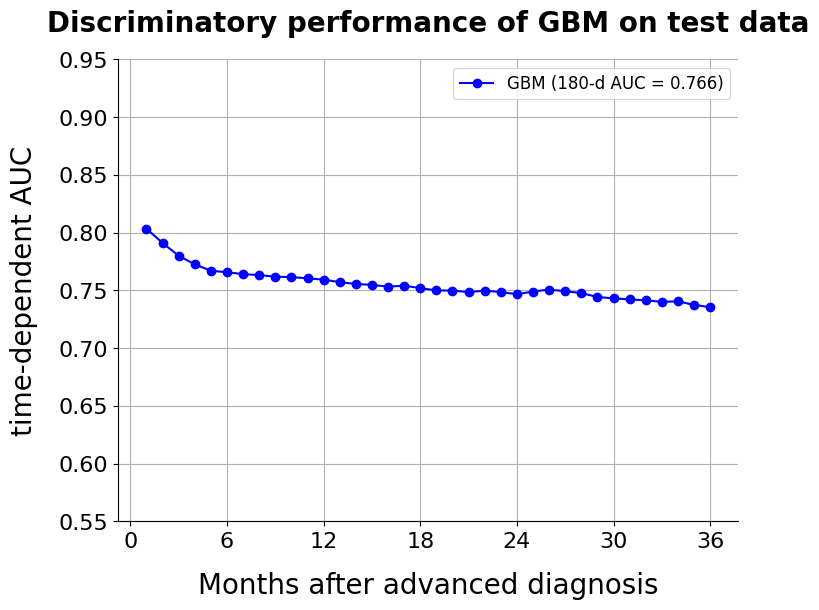

In [40]:
fig, ax0 = plt.subplots(figsize=(8, 6))

# Discriminatory performance plot
times = np.arange(30, 1095, 30)

ax0.plot(times/30, 
         gbm_auc_over5_df.loc['gbm'].values[0:36], 
         'o-', 
         color = 'blue', 
         label = f"GBM (180-d AUC = {final_auc_test:.3f})")

ax0.set_xticks(np.arange(0, 37, 6))
ax0.set_yticks(np.arange(0.55, 1.0, 0.05))
ax0.tick_params(axis = 'both', which = 'major', labelsize = 16) 

ax0.set_title('Discriminatory performance of GBM on test data', weight = 'bold', size = 20, pad = 20)
ax0.set_xlabel('Months after advanced diagnosis', labelpad = 15, size = 20)
ax0.set_ylabel('time-dependent AUC', labelpad = 15, size = 20)
ax0.legend(loc = 'upper right', prop = {'size': 12})
ax0.grid(True)

ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)

plt.show()

Total number of features: 122
Number of non-zero features in final model: 115


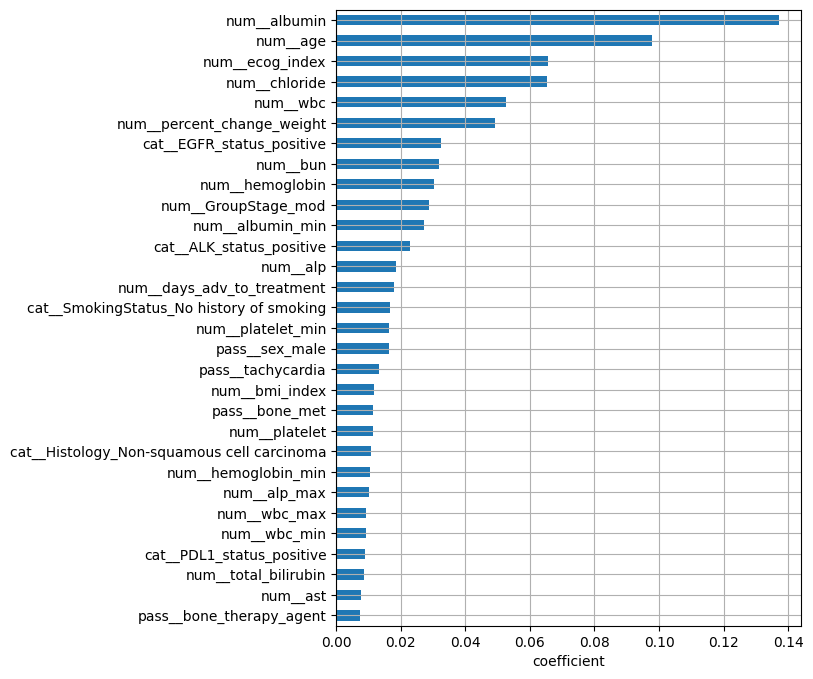

In [41]:
# Dataframe of coefficients for each variable 
gbm_feature_importance = pd.DataFrame(
    full_pipeline_final.named_steps['model'].feature_importances_,
    index = full_pipeline_final.named_steps['preprocessor'].get_feature_names_out(),
    columns = ['coefficient']
)

print('Total number of features: {}'.format(len(all_var)))

non_zero = np.sum(gbm_feature_importance.iloc[:, 0] != 0)
print('Number of non-zero features in final model: {}'.format(non_zero))

non_zero_coefs = gbm_feature_importance.query('coefficient != 0')
coef_order = non_zero_coefs.abs().sort_values('coefficient').tail(30).index

_, ax = plt.subplots(figsize=(6, 8))
non_zero_coefs.loc[coef_order].plot.barh(ax = ax, legend = False)
ax.set_xlabel('coefficient')
ax.grid(True)

In [42]:
gbm_feature_importance = (
    gbm_feature_importance
    .reset_index()
    .rename(columns = {'index':'variable'})
)

In [43]:
gbm_feature_importance.to_csv('../outputs/gbm_feature_importance.csv', index = False, header = True)

## Calculating risk scores and probability survival
**Risk scores are calculated for each patient using 3-fold cross-validation. For each fold, a model is trained on 67% of the data, and risk scores are generated for patients in the held-out 33%. This approach ensures that each patient's risk score and probability survival is based on a model that does not include them in training, providing unbiased predictions.**

### Preprocessing

In [44]:
df = pd.concat([train_df, test_df])

In [45]:
df.shape

(82739, 193)

In [46]:
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [47]:
model_params = {
    'n_estimators': 700,
    'learning_rate': 0.05,
    'max_depth': 3,
    'subsample': 0.75,
    'max_features': 0.7,
    'verbose': 1,
    'random_state': 42
}

cv_scores_df = cross_validated_survival_predictions(
    df = df,                      
    y = y,                      
    all_var = all_var,                 
    preprocessor = preprocessor,            
    model_params = model_params,            
    survival_timepoints = (180, 365),     
    tau = 365,                     
    n_splits = 3,              
    random_state = 42,         
    verbose = True  
)

Processing fold 1/3
      Iter       Train Loss      OOB Improve   Remaining Time 
         1      299541.7022          39.0400          395.78m
         2      298781.7219        -542.8905          391.24m
         3      298695.3198          62.3796          389.52m
         4      299447.3272         766.7866          388.88m
         5      298872.0054        -387.9976          387.83m
         6      299468.2320         646.9508          387.12m
         7      298769.1411        -520.5992          386.12m
         8      299411.4457         686.9252          385.41m
         9      298277.2784        -938.7932          384.78m
        10      299055.0449         788.0396          384.19m
        20      297302.6120        -172.9316          378.16m
        30      297309.3961        -195.5183          372.43m
        40      297730.4216        1206.2087          366.69m
        50      296572.7630         368.8788          360.07m
        60      296463.9925         418.6685     

In [48]:
cv_scores_df.to_csv('../outputs/gb_survival_predictions.csv')